# BurstCube Ancillary Data: Orbit, Attitude, GTI/SAA, HK, Timeline, Catalog

This notebook covers everything around the science data itself: spacecraft
position (`gdt.missions.burstcube.orbit`), attitude
(`gdt.missions.burstcube.attitude` and `gdt.missions.burstcube.frame`),
good-time-interval and SAA filtering (`gdt.missions.burstcube.gti`,
`gdt.missions.burstcube.saa`), detector housekeeping
(`gdt.missions.burstcube.hk`), the mission timeline
(`gdt.missions.burstcube.timeline`), and the observation catalog
(`gdt.missions.burstcube.catalog`). It uses the same day, 240530, as the
other two notebooks, plus the mission-long trend products (attitude, GTI,
timeline), which are not tied to any one day.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from gdt.missions.burstcube.finders import BurstCubeObsFinder, BurstCubeTrendFinder
from gdt.missions.burstcube.orbit import BurstCubeOrbit
from gdt.missions.burstcube.attitude import BurstCubeAttitude
from gdt.missions.burstcube.frame import BurstCubeFrame
from gdt.missions.burstcube.gti import BurstCubeGTI
from gdt.missions.burstcube.saa import BurstCubeSAA
from gdt.missions.burstcube.hk import BurstCubeHK
from gdt.missions.burstcube.timeline import BurstCubeTimeline
from gdt.missions.burstcube.catalog import BurstCubeObsCatalog
from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.core import data_path
from gdt.core.data_primitives import Gti

OBS_ID = '240530'
DETECTOR = 'CS0'
data_dir = Path(data_path) / 'burstcube' / OBS_ID
data_dir.mkdir(parents=True, exist_ok=True)
%matplotlib inline

## Orbit: spacecraft position and Earth position

The orbit file (`auxil/bcYYMMDD.hk.gz`) carries the reconstructed spacecraft
position/velocity, not attitude -- `INSTRUME='CS'` here, not a detector or
`'CSA'`. It converts directly to a `BurstCubeFrame` with
`obsgeoloc`/`obsgeovel` set and no quaternion, which is enough for
Earth-visibility/geocenter work but not for sky positions.

In [2]:
finder = BurstCubeObsFinder(OBS_ID)
orbit_path = finder.get_orbit(data_dir)
print(f'orbit file: {orbit_path}')

orbit = BurstCubeOrbit.open(orbit_path)
frame = orbit.get_spacecraft_frame()
print(f'{len(frame.obstime)} orbit rows, time range '
     f'{frame.obstime.min().burstcube:.1f} to {frame.obstime.max().burstcube:.1f} (MET)')

import astropy.units as u

loc = frame.obsgeoloc
r_km = np.sqrt(loc.x**2 + loc.y**2 + loc.z**2).to(u.km)
print(f'spacecraft geocentric distance: min={r_km.min().value:.1f} km, '
     f'max={r_km.max().value:.1f} km')
print(f'no quaternion on this frame: {frame.quaternion is None}')

Output()

orbit file: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530.hk.gz
2899 orbit rows, time range 107568002.4 to 107654372.9 (MET)
spacecraft geocentric distance: min=6766.3 km, max=6776.1 km
no quaternion on this frame: True


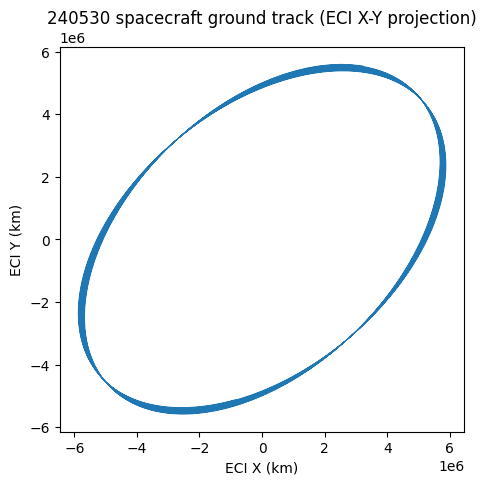

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(loc.x.value, loc.y.value, lw=0.5)
ax.set_xlabel('ECI X (km)')
ax.set_ylabel('ECI Y (km)')
ax.set_title(f'{OBS_ID} spacecraft ground track (ECI X-Y projection)')
ax.set_aspect('equal')
plt.show()

## Attitude: the 3 reconstructed epochs, and supplying your own quaternion

Per archive caveat #1, real reconstructed attitude exists for only 3 brief
epochs across the entire mission, with ~10-12 deg pointing errors even then.
That figure is not in the FITS file -- it comes from `trend/README` and the
caveat -- so treat it as order-of-magnitude. These were manually derived based on solar and magnetic sensors. `trend/attitude/bc_csa_att.fits`
exposes exactly those 3 rows and deliberately does **not** interpolate
between them: doing so would fabricate data the mission does not have.

In [4]:
trend_finder = BurstCubeTrendFinder()
att_path = trend_finder.get_attitude(data_dir)
print(f'attitude file: {att_path.name}')

att = BurstCubeAttitude.open(att_path)
print(f'{att.num_rows} attitude epochs in the whole archive')
for i in range(att.num_rows):
    ra, dec, roll = att.pointing[i]
    print(f'  epoch {i}: MET={att.time[i].burstcube:.3f}  '
         f'boresight RA={ra:.4f} Dec={dec:.4f}  roll={roll:.4f}')

Output()

attitude file: bc_csa_att.fits
3 attitude epochs in the whole archive
  epoch 0: MET=110220808.000  boresight RA=48.7231 Dec=10.8619  roll=333.9504
  epoch 1: MET=111198020.000  boresight RA=350.9859 Dec=49.4582  roll=297.4166
  epoch 2: MET=111465000.000  boresight RA=182.6820 Dec=-46.0375  roll=69.1484


In [5]:
# Use epoch 0's own frame to recover its own documented boresight pointing,
# as a check that the quaternion convention (scalar-last QPARAM) round-trips.
# The frame's own representation is (az, el) -- el, not zenith -- with the
# boresight at az=0, el=90.
from astropy.coordinates import SkyCoord

epoch = 0
epoch_frame = att.frame(epoch)
boresight = SkyCoord(az=0, el=90, unit='deg', frame=epoch_frame).icrs
ra_doc, dec_doc, roll_doc = att.pointing[epoch]
print(f'reconstructed boresight: RA={np.asarray(boresight.ra.deg).item():.6f}, '
     f'Dec={np.asarray(boresight.dec.deg).item():.6f}')
print(f'file POINTING column:    RA={ra_doc:.6f}, Dec={dec_doc:.6f}')

reconstructed boresight: RA=48.723068, Dec=10.861863
file POINTING column:    RA=48.723068, Dec=10.861862


For every other time -- essentially all of the mission, including this
notebook's worked day, 240530, which does not coincide with any of the 3
epochs -- there is no attitude file to open. If a new attitude is deduced in the future,
the path is to
supply your own reconstructed quaternion via
`BurstCubeFrame.from_quaternion`. Here we reuse epoch 0's real quaternion as
a stand-in, retimed to a moment during 240530, purely to demonstrate the
mechanism -- this is **not** a claim that the spacecraft was actually at
that orientation on 240530.

In [6]:
from astropy.time import Time as AstropyTime
from astropy.coordinates import SkyCoord

demo_quaternion = att.quaternion[0].scalar_last  # the 4 floats (x, y, z, w)
demo_time = AstropyTime('2024-05-30T12:00:00')
user_frame = BurstCubeFrame.from_quaternion(demo_quaternion, demo_time)

demo_coord = SkyCoord(ra=48.723068, dec=10.861862, unit='deg')
sc_coord = demo_coord.transform_to(user_frame)
az = np.asarray(sc_coord.az.deg).item()
zen = 90.0 - np.asarray(sc_coord.el.deg).item()
print(f'RA/Dec -> spacecraft frame: az={az:.4f}, zen={zen:.4f}')
print('zen=0 as expected: this is the same quaternion whose own documented')
print('boresight is this exact RA/Dec, just retimed.')

RA/Dec -> spacecraft frame: az=283.6370, zen=0.0000
zen=0 as expected: this is the same quaternion whose own documented
boresight is this exact RA/Dec, just retimed.


## GTI and SAA filtering

Three different kinds of "good time" apply to BurstCube data: the per-file
`STDGTI` extension bundled with CBD/TTE, the standalone mission-long trend
GTI files (valid-binning, positive-counts, SAA in/out), and the SAA
boundary polygon itself (a geographic region, not a time interval).

In [7]:
gti_path = trend_finder.get_gti_saa(data_dir, variant='in_cl')
print(f'SAA trend GTI file: {gti_path}')
saa_gti = BurstCubeGTI.open(gti_path).gti
saa_intervals = saa_gti.as_list()
print(f'{len(saa_intervals)} SAA-passage intervals in the trend file')
print(f'first 3: {saa_intervals[:3]}')

Output()

SAA trend GTI file: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc_csa_saa_in_cl.gti
586 SAA-passage intervals in the trend file
first 3: [(107629482.71931195, 107630000.214), (107630001.238, 107630322.71931219), (107632062.71931195, 107632546.86)]


In [8]:
cl_path = finder.get_cbd(data_dir, detectors=DETECTOR, variant='cl')[0]
uf_path = finder.get_cbd(data_dir, detectors=DETECTOR, variant='uf')[0]
cbd_cl = BurstCubeCBD.open(cl_path)
cbd_uf = BurstCubeCBD.open(uf_path)
print(f'_uf bins: {cbd_uf.data.size[0]}, own STDGTI: {len(cbd_uf.gti.as_list())} intervals')
print(f'_cl bins: {cbd_cl.data.size[0]}, own STDGTI: {len(cbd_cl.gti.as_list())} intervals')

gap_gti = BurstCubeGTI.complement(cbd_uf.gti, cbd_uf.data.tstart[0], cbd_uf.data.tstop[-1])
n_gaps = len(gap_gti.as_list()) if gap_gti is not None else 0
print(f'{n_gaps} gaps in the _uf GTI over its own time span -- the instrument was')
print('off or unstable this often even within a single observation day')

Output()

Output()

_uf bins: 98188, own STDGTI: 4 intervals
_cl bins: 12576, own STDGTI: 5 intervals
4 gaps in the _uf GTI over its own time span -- the instrument was
off or unstable this often even within a single observation day


In [9]:
# Cut the unfiltered file down to its own GTI, and to the mission-long SAA
# trend GTI. Either can be passed whole, in one call.
reconstructed = BurstCubeGTI.apply_to(cbd_uf.gti, cbd_uf)
print(f'_uf cut to its own {len(cbd_uf.gti.as_list())}-segment GTI: '
     f'{reconstructed.data.size[0]} bins (from {cbd_uf.data.size[0]})')

saa_filtered = BurstCubeGTI.apply_to(saa_gti, cbd_uf)
print(f'_uf cut to the {saa_gti.num_intervals}-interval SAA trend GTI: '
     f'{saa_filtered.data.size[0]} bins')

print(f'\narchive _cl file directly: {cbd_cl.data.size[0]} bins')

_uf cut to its own 4-segment GTI: 98184 bins (from 98188)
_uf cut to the 586-interval SAA trend GTI: 41799 bins

archive _cl file directly: 12576 bins


The `_uf` file's own `STDGTI` does not reproduce `_cl` on its own -- the
archive cleaning applies more than that one GTI.

(`apply_to` is not a thin wrapper: gdt-core's `slice_time` raises on both of
these inputs. The comments in `BurstCubeGTI.apply_to` say why.)

The SAA boundary itself is a static polygon in geographic
longitude/latitude, from CALDB, not a time interval -- it needs the
spacecraft's ground position (from the orbit file above) to turn into a
yes/no per time.

The CALDB file needs three corrections on the way in, all applied for you:

* **Its `X` and `Y` columns are latitude and longitude, not the
  longitude and latitude its own `TTYPE` comments claim.** Taken as
  labelled, one "latitude" reaches -94.3 deg, which is south of the south
  pole. Swapped back, the polygon spans 53.6S-2.0N by 94.3W-33.9E, which is
  the South Atlantic Anomaly -- and its first 11 vertices are numerically
  identical to Fermi GBM's `GbmSaaPolygon5`, where the same numbers live in
  explicitly named `_latitude` and `_longitude` lists.
* **Two pairs of vertices are listed out of order**, so the boundary doubles
  back and crosses itself twice, showing up as a spur off each of the
  eastern and western corners. Sorting by angle about the centroid removes
  both crossings and leaves the other 15 vertices exactly where the file
  puts them.
* **It is not closed.** The 19 vertices do not repeat the first point.
  `BurstCubeSAA` appends a 20th, which is why `is_closed()` below is True.

The README's *CALDB SAA polygon* caveat has the evidence for each.

In [10]:
saa = BurstCubeSAA()
print(f'SAA polygon: {len(saa.longitude)} vertices')

# BurstCubeOrbit gives ECI (GCRS) position; the SAA polygon is in geographic
# (Earth-fixed) longitude/latitude, so convert via ITRS -- a generic
# astropy operation, not BurstCube-specific.
from astropy.coordinates import GCRS, ITRS

gcrs = GCRS(loc, obstime=frame.obstime)
itrs = gcrs.transform_to(ITRS(obstime=frame.obstime))
earth = itrs.earth_location
ground_lon = earth.lon.deg
ground_lat = earth.lat.deg
print(f'ground track: lon range {ground_lon.min():.1f} to {ground_lon.max():.1f} deg, '
     f'lat range {ground_lat.min():.1f} to {ground_lat.max():.1f} deg')

SAA polygon: 20 vertices


ground track: lon range -180.0 to 179.9 deg, lat range -51.8 to 51.8 deg


337 of 2899 orbit rows this day fall inside the SAA polygon


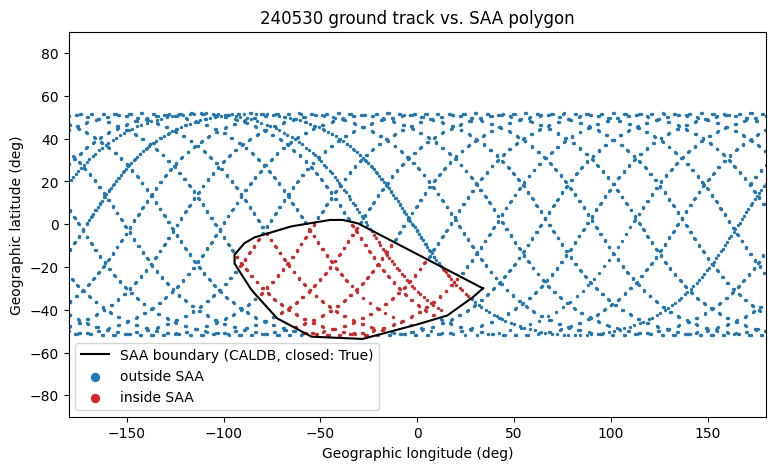

In [11]:
inside = saa.contains(ground_lon, ground_lat)
print(f'{inside.sum()} of {inside.size} orbit rows this day fall inside the SAA polygon')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(saa.longitude, saa.latitude, 'k-', lw=1.5,
       label=f'SAA boundary (CALDB, closed: {saa.is_closed()})')
ax.scatter(ground_lon[~inside], ground_lat[~inside], s=2, c='tab:blue', label='outside SAA')
ax.scatter(ground_lon[inside], ground_lat[inside], s=2, c='tab:red', label='inside SAA')
ax.set_xlabel('Geographic longitude (deg)')
ax.set_ylabel('Geographic latitude (deg)')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.legend(markerscale=4, loc='lower left')
ax.set_title(f'{OBS_ID} ground track vs. SAA polygon')
plt.show()

## Detector housekeeping: enable flags and energy thresholds

Per archive caveat #7, the per-detector energy thresholds were raised
mid-mission to suppress a non-Poissonian low-energy noise component.
`base_threshold` (from `DETECTOR_HK2`, 60 s cadence) carries that setting;
notebook 1 works through the change itself, and why the energy it
corresponds to reads ~20% below caveat #7's table. The enable flags (from
`DETECTOR_HK1`, 1 s cadence) show whether a detector's trigger and data
collection were actually turned on.

In [12]:
hk_path = finder.get_hk(data_dir)
hk = BurstCubeHK.open(hk_path)
print(f'HK1 (1 s cadence): {len(hk.hk1)} rows')
print(f'HK2 (60 s cadence): {len(hk.hk2)} rows')

for det in ('CS0', 'CS1', 'CS2', 'CS3'):
    base = hk.base_threshold(det)
    print(f'  {det}: BASE_THRES over the day: {base.min():.0f}-{base.max():.0f} mV, '
         f'DET_ENABLED fraction on: {hk.det_enabled(det).mean():.3f}')
print()
print('240530 sits entirely on one side of the mid-mission change, so')
print('BASE_THRES is flat all day -- see notebook 1 for a day that is not.')

Output()

HK1 (1 s cadence): 2110 rows
HK2 (60 s cadence): 1053 rows
  CS0: BASE_THRES over the day: 82-82 mV, DET_ENABLED fraction on: 0.997
  CS1: BASE_THRES over the day: 98-98 mV, DET_ENABLED fraction on: 0.997
  CS2: BASE_THRES over the day: 74-74 mV, DET_ENABLED fraction on: 0.997
  CS3: BASE_THRES over the day: 74-74 mV, DET_ENABLED fraction on: 0.997

240530 sits entirely on one side of the mid-mission change, so
BASE_THRES is flat all day -- see notebook 1 for a day that is not.


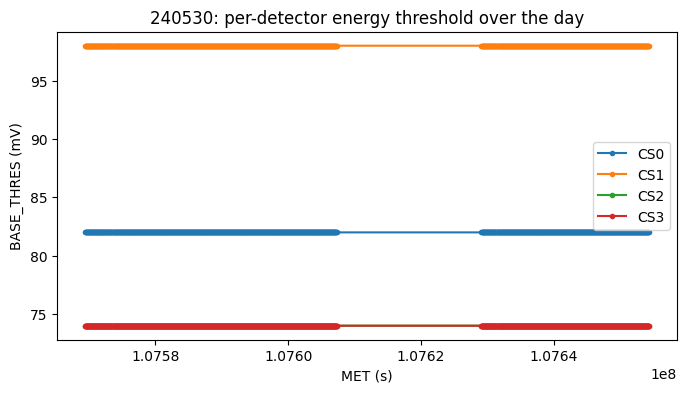

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for det in ('CS0', 'CS1', 'CS2', 'CS3'):
    ax.plot(hk.hk2.time.burstcube, hk.base_threshold(det), marker='o', ms=3, label=det)
ax.set_xlabel('MET (s)')
ax.set_ylabel('BASE_THRES (mV)')
ax.legend()
ax.set_title(f'{OBS_ID}: per-detector energy threshold over the day')
plt.show()

## The mission timeline

`trend/*_timeline_final.csv` is a reconstructed log of spacecraft and
instrument events -- power on/off, capture enabled/disabled, threshold
changes, clock drifts. Read the MET column, never the file's own UTC-string
column: the two are 37 s apart, for the reason set out in the README's
*Timeline UTC column is 37 seconds off its own MET column* caveat.
`BurstCubeTimeline` converts the MET for you, and exposes the CSV's string
as `utc_as_written` for provenance only.

In [14]:
timeline_path = trend_finder.get_timeline(data_dir)
print(f'timeline file: {timeline_path.name}')

timeline = BurstCubeTimeline.open(timeline_path)
print(f'{timeline.num_rows} timeline events across the mission')
print(f'spanning {timeline.time[0].utc.iso} to {timeline.time[-1].utc.iso}')

Output()

timeline file: 20250606_timeline_final.csv
505 timeline events across the mission
spanning 2024-05-16 02:32:35.280 to 2024-08-20 07:20:01.735


In [15]:
reboots = timeline.matching('Spacecraft Reboot')
print(f'{reboots.sum()} "Spacecraft Reboot" events in the timeline')

drift_rows = ~np.isnan(timeline.drift_seconds)
print(f'{drift_rows.sum()} "CBD Data Timestamp Drift (GPS Reboot)" events '
     f'with a parsed drift value')
if drift_rows.sum() > 0:
    print(f'drift magnitudes (s): {timeline.drift_seconds[drift_rows][:10]}')

68 "Spacecraft Reboot" events in the timeline
119 "CBD Data Timestamp Drift (GPS Reboot)" events with a parsed drift value
drift magnitudes (s): [-4.97 -0.26 -0.51 -0.51 -0.   -0.51  0.26 -0.26 -0.    0.26]


### What was on, and when

The caveats document's Figure 1 is a timeline of the instrument's state
across the mission. It can be rebuilt from this file: each subsystem logs a
matched pair of "Turned On" / "Turned Off" events, so pairing them gives the
intervals during which each was actually collecting.

This is the context for why there are only 7 TTE days and why day
directories are not contiguous -- the instrument itself was on for a small
fraction of the mission.

Instrument (HK)     55 intervals,  18.85 days on
CBD capture         65 intervals,  10.20 days on
TTE capture         14 intervals,   0.72 days on
On-board trigger    13 intervals,   0.68 days on


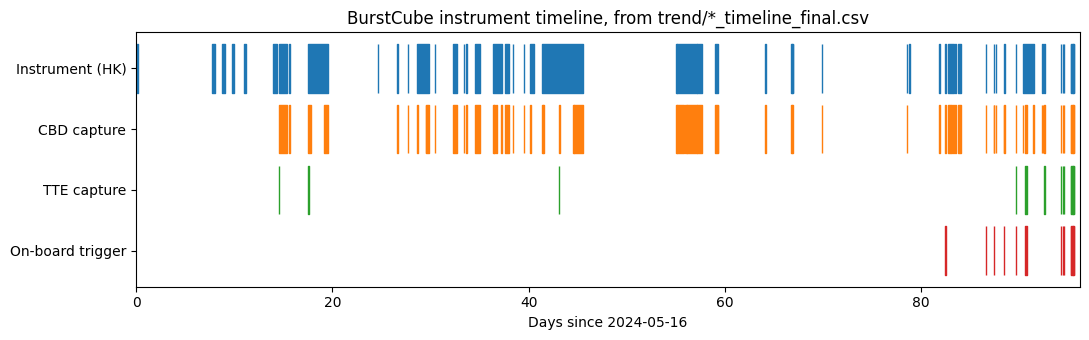

In [16]:
def on_off_intervals(timeline, on_text, off_text):
    """Pair "Turned On" events with the next "Turned Off" event.

    Returns (start, duration) pairs in MET, which is what `broken_barh`
    wants. An unterminated final "On" is dropped rather than guessed at.
    """
    met = timeline.time.burstcube
    starts = np.sort(met[timeline.matching(on_text)])
    stops = np.sort(met[timeline.matching(off_text)])

    intervals = []
    for start in starts:
        later = stops[stops > start]
        if later.size:
            intervals.append((start, later[0] - start))
    return intervals


SUBSYSTEMS = [
    ('Instrument (HK)', 'BurstCube Instrument (Housekeeping) Turned On',
     'BurstCube Instrument (Housekeeping) Turned Off'),
    ('CBD capture', 'Continous Binned Data (CBD) Capture Turned On',
     'Continous Binned Data (CBD) Capture Turned Off'),
    ('TTE capture', 'Time-Tagged Event (TTE) Capture Turned On',
     'Time-Tagged Event (TTE) Capture Turned Off'),
    ('On-board trigger', 'On-board Trigger Turned On',
     'On-board Trigger Turned Off'),
]

t0 = timeline.time[0].burstcube
fig, ax = plt.subplots(figsize=(11, 3.5))

for row, (label, on_text, off_text) in enumerate(SUBSYSTEMS):
    intervals = on_off_intervals(timeline, on_text, off_text)
    live = sum(duration for _, duration in intervals)
    ax.broken_barh([(start - t0, duration) for start, duration in intervals],
                  (row - 0.4, 0.8), color=f'C{row}')
    print(f'{label:18s} {len(intervals):3d} intervals, '
         f'{live / 86400:6.2f} days on')

span_days = (timeline.time[-1].burstcube - t0) / 86400
ax.set_yticks(range(len(SUBSYSTEMS)))
ax.set_yticklabels([label for label, _, _ in SUBSYSTEMS])
ax.set_xlim(0, span_days * 86400)
ax.set_xticks(np.arange(0, span_days + 1, 20) * 86400)
ax.set_xticklabels([f'{d:.0f}' for d in np.arange(0, span_days + 1, 20)])
ax.set_xlabel(f'Days since {timeline.time[0].utc.iso[:10]}')
ax.set_title('BurstCube instrument timeline, from trend/*_timeline_final.csv')
ax.invert_yaxis()

fig.tight_layout()
plt.show()

Reading this against the archive: the CBD row is why day directories exist
where they do, and the TTE row -- a handful of narrow bars -- is caveat #4's
"few TTE files" seen directly. The trigger row is on for a fair fraction of
the mission, but as caveat #7.2 notes it never produced an astrophysical
trigger, which is why there are no trigger-numbered products in the archive
at all.

Intervals are paired by taking each "Turned On" with the next "Turned Off".
The caveats document warns that the timeline is reconstructed from packet
types with different arrival cadences, so events within a few seconds of
each other can be logged out of order; at this scale that is invisible, but
do not read individual bar edges to the second.

## The observation catalog (`burcbmastr`)

The HEASARC Browse catalog gives one row per observation day, with
per-detector exposure/rate/integration-time columns. Missing values (a
detector with no CBD that day) are NaN, never coerced to 0.

In [17]:
catalog = BurstCubeObsCatalog(cached=False, verbose=False)
print(f'{catalog.num_rows} rows in burcbmastr')

tte_cat = catalog.tte_days()
print(f'{tte_cat.num_rows} days with TTE data (num_events > 0)')
print(f'TTE obs IDs: {sorted(tte_cat._data["OBSID"].tolist())}')

84 rows in burcbmastr
7 days with TTE data (num_events > 0)
TTE obs IDs: ['240530', '240602', '240628', '240629', '240813', '240814', '240815']


In [18]:
exp = catalog.exposure(DETECTOR)
n_missing = np.isnan(exp).sum()
print(f'{DETECTOR} exposure: {n_missing} of {catalog.num_rows} days have no CBD (NaN), '
     f'not zero')
print(f'of the days with CBD, mean exposure = {np.nanmean(exp):.1f} s, '
     f'max = {np.nanmax(exp):.1f} s')

CS0 exposure: 39 of 84 days have no CBD (NaN), not zero
of the days with CBD, mean exposure = 20895.2 s, max = 85217.8 s


## Summary

* The orbit file gives spacecraft position/velocity only -- no attitude.
* Real attitude exists for 3 epochs total, each with ~10-12 deg pointing
  error; every other time needs a user-supplied quaternion via
  `BurstCubeFrame.from_quaternion`.
* `BurstCubeGTI.apply_to` cuts a data product down to any GTI in one call,
  including the mission-long trend GTIs that gdt-core's own `slice_time`
  cannot be handed directly. The `_uf` file's own `STDGTI` does not by
  itself reproduce `_cl` -- the archive cleaning does more than that.
* The SAA boundary is a static geographic polygon needing ground position,
  not time. Its CALDB file stores latitude in `X` and longitude in `Y`,
  the opposite of its own header comments, and leaves the polygon open;
  `BurstCubeSAA` corrects both.
* Detector housekeeping carries the enable-flag history, and `BASE_THRES`
  carries the mid-mission energy threshold change.
* The timeline's MET column is authoritative; its own UTC-string column is
  wrong by 37 s and is kept only for reference. Pairing its on/off events
  rebuilds the caveats document's instrument timeline figure.
* The catalog's per-detector columns are NaN, not 0, for days with no data
  for that detector.